In [1]:
import torch, os, math, gzip, pickle
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from pathlib import Path

from torch import tensor
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io

In [2]:
path_img = Path('puppy.jpg')
if not path_img.exists(): urlretrieve(url, path_img)

In [3]:
img = io.read_image('puppy.jpg')
print(img.shape)
img[:2,:3,:4]

torch.Size([3, 965, 800])


tensor([[[9, 9, 7, 6],
         [9, 8, 7, 6],
         [9, 8, 7, 6]],

        [[9, 9, 7, 6],
         [9, 8, 7, 6],
         [9, 8, 7, 6]]], dtype=torch.uint8)

In [4]:
def show_img(x, figsize=(4,3), **kwargs):
    plt.figure(figsize=figsize)
    plt.axis('off')
    if len(x.shape)==3: x = x.permute(1,2,0)  # CHW -> HWC
    plt.imshow(x.cpu(), **kwargs)

In [5]:
img2 = tvf.resize(img, 150, antialias=True)
ch,h,w = img2.shape
ch,h,w,h*w

(3, 180, 150, 27000)

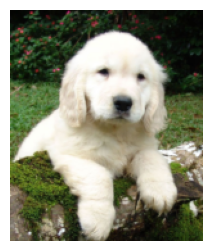

In [6]:
show_img(img2)

## Brute Force

In [7]:
def blur(x, kern):
    _,h,w = x.shape
    n=h*w
    kernel_size = 3
    r = kernel_size // 2
    x = x.flatten()

    ix = 0
    iy = 0
    res = [0.0] * n
    sum_ = 0.0
    for i in range(n):
        ix, iy = i % kernel_size, i // kernel_size
        for j in range(-r, r+1):
            for k in range(-r, r+1):
                x_idx = min(max(j + ix % kernel_size, 0), w-1)
                y_idx = min(max(k + iy % kernel_size, 0), h-1)
                sum_ += x[y_idx * w + x_idx] * kern[(y_idx + r) * 3 + (x_idx + r)]
        res[i] = sum_
    return res


In [8]:
img2.shape

torch.Size([3, 180, 150])

In [9]:
def run_kernel(f, times, width, *args):
    for i in range(times):
        ix, iy = i % width, i // width
        f(ix, iy, *args)

def blur_k(ix, iy, x, kern, res, h, w):
    r = 1
    sum_ = 0.0
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            sx = min(max(ix + dx, 0), w - 1)  
            sy = min(max(iy + dy, 0), h - 1)
            sum_ += x[sy * w + sx] * kern[(dy + r) * 3 + (dx + r)]
    res[iy * w + ix] = sum_          

def blur_pykernel(x, kernel):
    _, h, w = x.shape
    n = h * w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    run_kernel(blur_k, n, w, x, kernel, res, h, w)  
    return res.view(h, w)

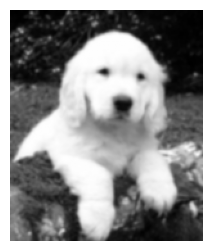

In [10]:
kern = torch.tensor([1,2,1,2,4,2,1,2,1], dtype=torch.float32)
kern = kern / kern.sum() 
img_g = blur_pykernel(img2, kern)
show_img(img_g, cmap='gray')

## Block Kernel Simulation

In [11]:
def run_kernel_blk(f, num_blocks, num_threads,*args):
    for block_idx in range(num_blocks):
        for thread_idx in range(num_threads):
            f(block_idx, thread_idx, num_threads, *args)

def kernel_operation(block_idx, thread_idx, num_threads, x, kern, res):
    global_ix = block_idx * num_threads + thread_idx
    ix, iy = global_ix % w, global_ix // w
    if global_ix >= h * w:
        return
    r = 1
    sum_ = 0.0
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            sx = min(max(ix + dx, 0), w - 1)  
            sy = min(max(iy + dy, 0), h - 1)
            sum_ += x[sy * w + sx] * kern[(dy + r) * 3 + (dx + r)]
    res[iy * w + ix] = sum_

def blk_kernel_launch(x, kernel):
    _, h, w = x.shape
    n = h*w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)

    num_threads = 256
    num_blocks = int(math.ceil(n/num_threads))

    run_kernel_blk(kernel_operation, num_blocks, num_threads, x, kernel, res)
    return res.view(h, w)


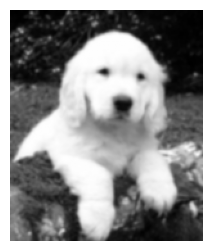

In [12]:
kern = torch.tensor([1,2,1,2,4,2,1,2,1], dtype=torch.float32)
kern = kern / kern.sum() 
img_g = blk_kernel_launch(img2, kern)
show_img(img_g, cmap='gray')

In [13]:
from cuda_utils import load_cuda, cuda_begin

In [14]:
cuda_src = cuda_begin + r'''
__global__ void apply_kernel_kernel(unsigned char* x, unsigned char* res, int w, int h, float* kern) {
   int gloval_ix = blockIdx.x * blockDim.x + threadIdx.x;
   if (gloval_ix >= w * h) return;
   int ix = gloval_ix % w;
   int iy = gloval_ix / w;

   int r = 1;
   float sum = 0.0;

   for (int dy = -r; dy < r+1; dy++) {
      for (int dx = -r; dx < r+1; dx++) {
         int sx = min(max(ix + dx, 0), w - 1);
         int sy = min(max(iy + dy, 0), h - 1);
         sum += x[sy * w + sx] * kern[(dy + r) * 3 + (dx + r)];
      }
   }
   res[iy * w + ix] = (unsigned char)(sum);
}

torch::Tensor apply_kernel(torch::Tensor input, torch::Tensor kernel) {
   CHECK_INPUT(input);
   int h = input.size(0);
   int w = input.size(2);
   printf("h*w: %d*%d\n", h, w);
   
   auto output = torch::empty({h,w}, input.options());
   int threads = 256;
   apply_kernel_kernel<<<cdiv(w*h,threads), threads>>>(
      input.data_ptr<unsigned char>(), 
      output.data_ptr<unsigned char>(), 
      w,
      h,
      kernel.data_ptr<float>() 
   );
   C10_CUDA_KERNEL_LAUNCH_CHECK();
   return output;
}
'''

In [15]:
cpp_src = "torch::Tensor apply_kernel(torch::Tensor input, torch::Tensor kernel);"

In [16]:
module = load_cuda(cuda_src, cpp_src, ['apply_kernel'])
print(module)

<module 'inline_ext_217c7663' from 'C:\\Users\\derek\\AppData\\Local\\torch_extensions\\torch_extensions\\Cache\\py313_cu126\\inline_ext_217c7663\\inline_ext_217c7663.pyd'>


In [17]:
dir(module)

['__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'apply_kernel']

In [18]:
imgc = img.contiguous().cuda()
kern = torch.tensor([1,2,1,2,4,2,1,2,1], dtype=torch.float32)
kern = kern / kern.sum() 
kern = kern.cuda()

In [19]:
%%time
kern_cuda = kern.cuda()
img_channel = img2[0].contiguous().cuda()   # pick one channel
res = module.apply_kernel(img_channel, kern_cuda).cpu()
h, w = res.shape
h, w, h*w

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)